# Example of Standardization - Feature scaling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## DF Reading 

In [2]:
df = pd.read_csv("F:\Datasets and ML\datasets\Social_Network_Ads.csv")

In [3]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [4]:
from sklearn.model_selection import train_test_split


In [5]:
 X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3, random_state=11)

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

In [8]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [9]:
scaler.mean_

array([3.76964286e+01, 7.14142857e+04])

In [10]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.696429,71414.285714
std,10.497174,35056.531041
min,18.000000,15000.000000
25%,30.000000,44000.000000
50%,37.000000,71000.000000
75%,46.000000,89000.000000
max,60.000000,150000.000000


In [11]:
X_train_scaled = scaler.transform(X_train)

In [12]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)

In [13]:
X_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,1.808077e-16,1.157804e-16
std,1.001791e+00,1.001791e+00
min,-1.879715e+00,-1.612119e+00
25%,-7.345033e-01,-7.834024e-01
50%,-6.646318e-02,-1.183881e-02
75%,7.924456e-01,5.025369e-01
max,2.128526e+00,2.245699e+00


In [14]:
X_test_scaled = scaler.transform(X_test)

In [15]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_train.columns)

In [16]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,-0.0
75%,0.8,0.5
max,2.1,2.2


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
model_scale = LinearRegression()

In [22]:
model_scale.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred_scaled = model_scale.predict(X_test_scaled)

In [24]:
from sklearn.metrics import r2_score

In [25]:
r2_score(y_test, y_pred)

0.4316910315506053

In [26]:
r2_score(y_test, y_pred_scaled)

0.4316910315506054

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
model = LogisticRegression()
model_scaled = LogisticRegression()
model.fit(X_train,y_train)
model_scaled.fit(X_train_scaled,y_train)
y_pred = model_scaled.predict(X_test)
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
print(f"Actual Score : {accuracy_score(y_test,y_pred)}")
print(f"After Scaling : {accuracy_score(y_test,y_pred_scaled)}")

Actual Score : 0.3416666666666667
After Scaling : 0.825


In [31]:
accuracy_score(y_test,y_pred_scaled)

0.825

C:\Users\DELL\AppData\Local\Temp\ipykernel_22640\631139551.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


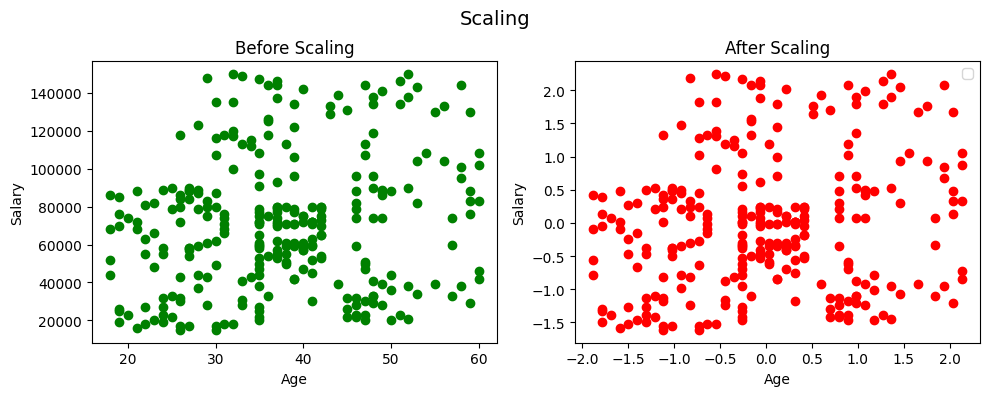

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].scatter(X_train['Age'], X_train['EstimatedSalary'],color='g')
axs[0].set_title('Before Scaling')
axs[0].set_xlabel('Age')             # <--- X label
axs[0].set_ylabel('Salary') 

axs[1].scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
axs[1].set_title('After Scaling')
axs[1].set_xlabel('Age')             # <--- X label
axs[1].set_ylabel('Salary') 
 
fig.suptitle('Scaling', fontsize=14)
fig.tight_layout()
plt.legend()
fig.subplots_adjust(top=0.85)  # So title doesn't overlap

## PDF

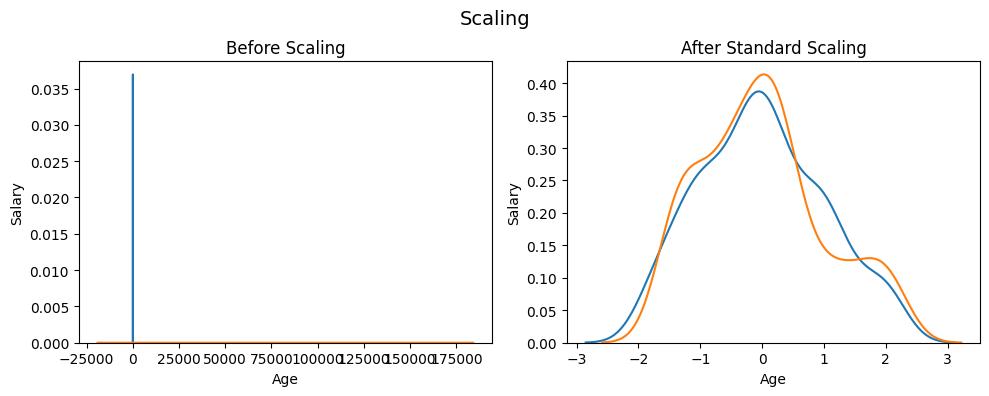

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#axs[0].kde(X_train['Age'], X_train['EstimatedSalary'],color='g')
axs[0].set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=axs[0]) 
sns.kdeplot(X_train['EstimatedSalary'],ax=axs[0])
axs[0].set_xlabel('Age')             # <--- X label
axs[0].set_ylabel('Salary') 

# axs[1].scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
axs[1].set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=axs[1]) 
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=axs[1])
axs[1].set_xlabel('Age')             # <--- X label
axs[1].set_ylabel('Salary') 
 
fig.suptitle('Scaling', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)  # So title doesn't overlap

In [34]:
type(axs)

numpy.ndarray

,Age,EstimatedSalary
0,-1.593412,0.016738
1,0.219840,0.016738
2,-0.352766,-0.811979
3,-0.161897,1.559865
4,0.887880,-0.697673
...,...,...
275,0.219840,-0.297603
276,-0.257332,0.216773
277,-0.734503,1.274101
278,-0.734503,0.245349


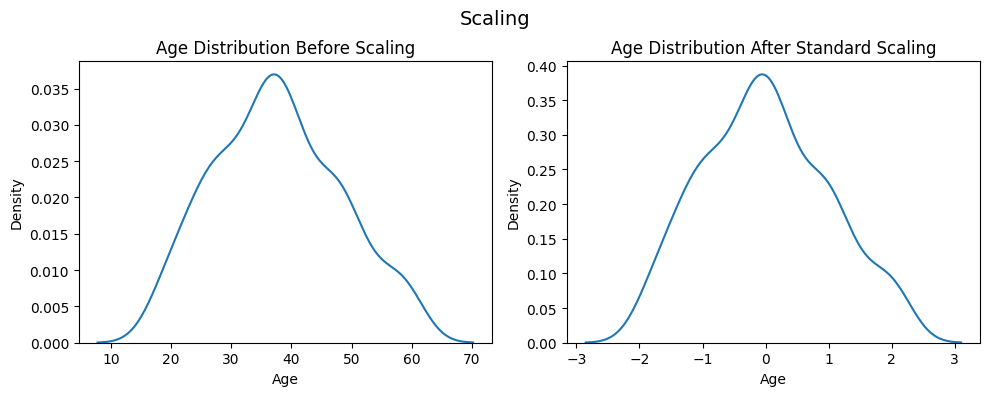

In [85]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#axs[0].kde(X_train['Age'], X_train['EstimatedSalary'],color='g')
axs[0].set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'],ax=axs[0]) 



# axs[1].scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
axs[1].set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=axs[1]) 


 
fig.suptitle('Scaling', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)  # So title doesn't overlap

# Outlier Impact:
-- outlier won't be affected in standardization it will be preserved as is

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [147]:
df = pd.concat([df,pd.DataFrame({"Age":[5,90,95],"EstimatedSalary" : [1000,250000,350000],"Purchased":[0,1,1]})],ignore_index=True)

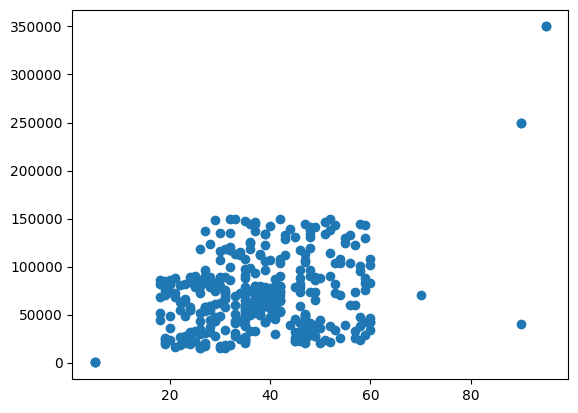

In [148]:
plt.scatter(df['Age'],df['EstimatedSalary'])